Loading data...
Analyzing correlation between VO/OV order and possessor-possessum order...
Total languages with valid VO and possessor order: 1844

Contingency Table (counts):
PSSR_Order  PSSD-PSSR  PSSR-PSSD
VO_Order                        
OV                101        718
VO                738        287

Percentage Table (row %):
PSSR_Order  PSSD-PSSR  PSSR-PSSD
VO_Order                        
OV          12.332112  87.667888
VO          72.000000  28.000000

Chi-square test: χ² = 651.21, p = 0.00000000, df = 1
Cramer's V: 0.5943
Interpretation: strong association

Testing Dryer's predictions:
OV languages with PSSR-PSSD order: 87.7%
VO languages with PSSD-PSSR order: 72.0%
✓ PSSR-PSSD does correlate with OV as predicted
✓ PSSD-PSSR does correlate with VO as predicted

Head-marking languages with valid VO and possessor order: 676

Contingency Table for Head-marking Languages (counts):
PSSR_Order  PSSD-PSSR  PSSR-PSSD
VO_Order                        
OV                 38        237

/var/folders/jk/cgmd03wn0g1b85mr8y_w4__c0000gn/T/ipykernel_9366/744433751.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['VO_Order'] = 'Unknown'
/var/folders/jk/cgmd03wn0g1b85mr8y_w4__c0000gn/T/ipykernel_9366/744433751.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['PSSR_Order'] = 'Unknown'


<Figure size 1000x600 with 0 Axes>

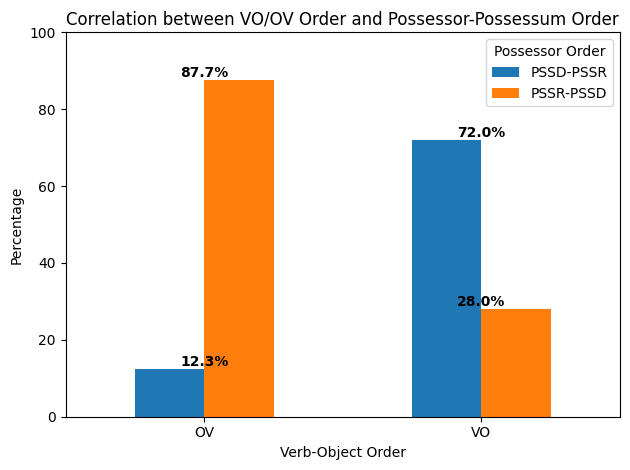

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt  # ← MISSING IN ORIGINAL!

def analyze_vo_pssr_correlation(data):
    """Analyze correlation between VO/OV word order and possessor-possessum order"""
    
    print("Analyzing correlation between VO/OV order and possessor-possessum order...")
    
    # Create verb-object order feature
    # GB131: V-initial -> VO
    # GB132: V-medial -> VO (since OVS is rare)
    # GB133: V-final -> OV
    data['VO_Order'] = 'Unknown'
    data.loc[(data['GB131'] == '1') | (data['GB132'] == '1'), 'VO_Order'] = 'VO'
    data.loc[data['GB133'] == '1', 'VO_Order'] = 'OV'
    
    # Possessor-possessum order
    # GB065 = '1': PSSR-PSSD
    # GB065 = '2': PSSD-PSSR
    data['PSSR_Order'] = 'Unknown'
    data.loc[data['GB065'] == '1', 'PSSR_Order'] = 'PSSR-PSSD'
    data.loc[data['GB065'] == '2', 'PSSR_Order'] = 'PSSD-PSSR'
    
    # Filter out languages with unknown values
    valid_data = data[(data['VO_Order'] != 'Unknown') & (data['PSSR_Order'] != 'Unknown')]
    
    print(f"Total languages with valid VO and possessor order: {len(valid_data)}")
    
    # Create contingency table
    contingency = pd.crosstab(valid_data['VO_Order'], valid_data['PSSR_Order'])
    print("\nContingency Table (counts):")
    print(contingency)
    
    # Create percentage table
    percentage = pd.crosstab(
        valid_data['VO_Order'], 
        valid_data['PSSR_Order'], 
        normalize='index'
    ) * 100
    print("\nPercentage Table (row %):")
    print(percentage)
    
    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p:.8f}, df = {dof}")
    
    # Calculate Cramer's V
    n = np.sum(contingency.values)
    phi2 = chi2 / n
    r, k = contingency.shape
    cramers_v = np.sqrt(phi2 / min((k-1), (r-1)))
    print(f"Cramer's V: {cramers_v:.4f}")
    
    # Interpret Cramer's V
    if cramers_v < 0.1:
        interpretation = "negligible association"
    elif cramers_v < 0.2:
        interpretation = "weak association"
    elif cramers_v < 0.3:
        interpretation = "moderate association"
    else:
        interpretation = "strong association"
    print(f"Interpretation: {interpretation}")
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    ax = percentage.plot(kind='bar', rot=0)
    plt.title('Correlation between VO/OV Order and Possessor-Possessum Order')
    plt.xlabel('Verb-Object Order')
    plt.ylabel('Percentage')
    plt.ylim(0, 100)
    
    # Add value labels on bars
    for i, p in enumerate(percentage.values):
        for j, val in enumerate(p):
            ax.annotate(f'{val:.1f}%', (i, val), 
                        ha='center', va='bottom', fontweight='bold')
    
    plt.legend(title='Possessor Order')
    plt.tight_layout()
    plt.savefig('vo_pssr_correlation.png')
    
    # Test if the correlation matches Dryer's prediction
    ov_pssr_pssd_percent = percentage.loc['OV', 'PSSR-PSSD'] if 'OV' in percentage.index and 'PSSR-PSSD' in percentage.columns else 0
    vo_pssd_pssr_percent = percentage.loc['VO', 'PSSD-PSSR'] if 'VO' in percentage.index and 'PSSD-PSSR' in percentage.columns else 0
    
    print("\nTesting Dryer's predictions:")
    print(f"OV languages with PSSR-PSSD order: {ov_pssr_pssd_percent:.1f}%")
    print(f"VO languages with PSSD-PSSR order: {vo_pssd_pssr_percent:.1f}%")
    
    if ov_pssr_pssd_percent > 50:
        print("✓ PSSR-PSSD does correlate with OV as predicted")
    else:
        print("✗ PSSR-PSSD does NOT correlate with OV as predicted")
        
    if vo_pssd_pssr_percent > 50:
        print("✓ PSSD-PSSR does correlate with VO as predicted")
    else:
        print("✗ PSSD-PSSR does NOT correlate with VO as predicted")
    
    # Look at the results for head-marking languages
    head_marking = data[(data['GB431'] == '1') | (data['GB433'] == '1')].copy()
    head_marking['VO_Order'] = 'Unknown'
    head_marking.loc[(head_marking['GB131'] == '1') | (head_marking['GB132'] == '1'), 'VO_Order'] = 'VO'
    head_marking.loc[head_marking['GB133'] == '1', 'VO_Order'] = 'OV'
    
    head_marking['PSSR_Order'] = 'Unknown'
    head_marking.loc[head_marking['GB065'] == '1', 'PSSR_Order'] = 'PSSR-PSSD'
    head_marking.loc[head_marking['GB065'] == '2', 'PSSR_Order'] = 'PSSD-PSSR'
    
    valid_head_marking = head_marking[(head_marking['VO_Order'] != 'Unknown') & 
                                     (head_marking['PSSR_Order'] != 'Unknown')]
    
    print(f"\nHead-marking languages with valid VO and possessor order: {len(valid_head_marking)}")
    
    if len(valid_head_marking) > 0:
        # Create contingency table for head-marking languages
        hm_contingency = pd.crosstab(valid_head_marking['VO_Order'], valid_head_marking['PSSR_Order'])
        print("\nContingency Table for Head-marking Languages (counts):")
        print(hm_contingency)
        
        # Create percentage table for head-marking languages
        hm_percentage = pd.crosstab(
            valid_head_marking['VO_Order'], 
            valid_head_marking['PSSR_Order'], 
            normalize='index'
        ) * 100
        print("\nPercentage Table for Head-marking Languages (row %):")
        print(hm_percentage)
        
        # Chi-square test for head-marking languages
        if min(hm_contingency.shape) > 1 and np.all(hm_contingency.values >= 5):
            hm_chi2, hm_p, hm_dof, hm_expected = chi2_contingency(hm_contingency)
            print(f"\nChi-square test (head-marking): χ² = {hm_chi2:.2f}, p = {hm_p:.8f}, df = {hm_dof}")
            
            # Calculate Cramer's V for head-marking languages
            hm_n = np.sum(hm_contingency.values)
            hm_phi2 = hm_chi2 / hm_n
            hm_r, hm_k = hm_contingency.shape
            hm_cramers_v = np.sqrt(hm_phi2 / min((hm_k-1), (hm_r-1)))
            print(f"Cramer's V (head-marking): {hm_cramers_v:.4f}")
        else:
            print("\nNote: Sample size too small for chi-square test on head-marking languages")
    
    return valid_data, contingency, percentage

def main():
    # Load data
    print("Loading data...")
    grambank = pd.read_csv('grambank_sane_format.csv')
    
    # Convert columns to string
    for col in grambank.columns:
        if col.startswith('GB'):
            grambank[col] = grambank[col].astype(str)
    
    # Analyze correlation
    analyze_vo_pssr_correlation(grambank)
    
    print("\nAnalysis complete! Results also saved to 'vo_pssr_correlation.png'")

if __name__ == "__main__":
    main()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from tqdm import tqdm


def analyze_vo_pssr_correlation(data, sample_num=None, verbose=False):
    """Analyze correlation between VO/OV word order and possessor-possessum order"""
    
    # Create verb-object order feature
    # GB131: V-initial -> VO
    # GB132: V-medial -> VO (since OVS is rare)
    # GB133: V-final -> OV
    data = data.copy()
    data['VO_Order'] = 'Unknown'
    data.loc[(data['GB131'] == '1') | (data['GB132'] == '1'), 'VO_Order'] = 'VO'
    data.loc[data['GB133'] == '1', 'VO_Order'] = 'OV'
    
    # Possessor-possessum order
    # GB065 = '1': PSSR-PSSD
    # GB065 = '2': PSSD-PSSR
    data['PSSR_Order'] = 'Unknown'
    data.loc[data['GB065'] == '1', 'PSSR_Order'] = 'PSSR-PSSD'
    data.loc[data['GB065'] == '2', 'PSSR_Order'] = 'PSSD-PSSR'
    
    # Filter out languages with unknown values
    valid_data = data[(data['VO_Order'] != 'Unknown') & (data['PSSR_Order'] != 'Unknown')]
    
    if len(valid_data) < 10:  # Need minimum sample size
        return None
    
    # Create contingency table
    contingency = pd.crosstab(valid_data['VO_Order'], valid_data['PSSR_Order'])
    
    # Calculate percentages
    percentage = pd.crosstab(
        valid_data['VO_Order'], 
        valid_data['PSSR_Order'], 
        normalize='index'
    ) * 100
    
    # Chi-square test
    try:
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        # Calculate Cramer's V
        n = np.sum(contingency.values)
        phi2 = chi2 / n
        r, k = contingency.shape
        cramers_v = np.sqrt(phi2 / min((k-1), (r-1)))
    except:
        chi2, p, cramers_v = np.nan, np.nan, np.nan
    
    # Get key percentages for Dryer's predictions
    ov_pssr_pssd = percentage.loc['OV', 'PSSR-PSSD'] if 'OV' in percentage.index and 'PSSR-PSSD' in percentage.columns else np.nan
    vo_pssd_pssr = percentage.loc['VO', 'PSSD-PSSR'] if 'VO' in percentage.index and 'PSSD-PSSR' in percentage.columns else np.nan
    
    if verbose:
        print(f"\nSample {sample_num}:")
        print(f"Total valid languages: {len(valid_data)}")
        print(f"Cramer's V: {cramers_v:.4f}")
        print(f"OV → PSSR-PSSD: {ov_pssr_pssd:.1f}%")
        print(f"VO → PSSD-PSSR: {vo_pssd_pssr:.1f}%")
        print("-" * 50)
    
    return {
        'sample': sample_num,
        'n_languages': len(valid_data),
        'chi2': chi2,
        'p_value': p,
        'cramers_v': cramers_v,
        'ov_pssr_pssd_pct': ov_pssr_pssd,
        'vo_pssd_pssr_pct': vo_pssd_pssr,
        'ov_count': contingency.loc['OV'].sum() if 'OV' in contingency.index else 0,
        'vo_count': contingency.loc['VO'].sum() if 'VO' in contingency.index else 0
    }


def analyze_vo_pssr_head_marking(data, sample_num=None, verbose=False):
    """Same analysis but for head-marking languages only"""
    
    # Filter for head-marking
    if 'GB431' not in data.columns or 'GB433' not in data.columns:
        return None
    
    head_marking = data[(data['GB431'] == '1') | (data['GB433'] == '1')].copy()
    
    if len(head_marking) < 10:
        return None
    
    return analyze_vo_pssr_correlation(head_marking, sample_num, verbose)


def create_stratified_sample(data, langs_per_area=20):
    """Create genealogically balanced sample"""
    sampled_data = pd.DataFrame()
    
    # Get macroareas from data
    macroareas = data['Macroarea'].dropna().unique()
    
    for area in macroareas:
        area_data = data[data['Macroarea'] == area].copy()
        if area_data.empty:
            continue
            
        families = area_data['Family'].unique()
        families = families[~pd.isna(families)]
        
        if len(families) == 0:
            continue
            
        num_to_sample = min(len(families), langs_per_area)
        selected_families = np.random.choice(families, size=num_to_sample, replace=False)
            
        area_sample = pd.DataFrame()
        for family in selected_families:
            family_data = area_data[area_data['Family'] == family]
            if not family_data.empty:
                sampled_lang = family_data.sample(n=1)
                area_sample = pd.concat([area_sample, sampled_lang])
        
        sampled_data = pd.concat([sampled_data, area_sample])
    
    return sampled_data


def visualize_results(all_langs_results, head_marking_results):
    """Create visualizations comparing results"""
    
    # Convert to DataFrames
    all_df = pd.DataFrame([r for r in all_langs_results if r is not None])
    hm_df = pd.DataFrame([r for r in head_marking_results if r is not None])
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # 1. Cramer's V distribution - All languages
    ax = axes[0, 0]
    if len(all_df) > 0:
        sns.histplot(all_df['cramers_v'].dropna(), kde=True, bins=20, ax=ax, color='steelblue')
        ax.axvline(all_df['cramers_v'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {all_df['cramers_v'].mean():.3f}")
        ax.set_xlabel("Cramer's V")
        ax.set_ylabel('Count')
        ax.set_title('All Languages: Cramer\'s V Distribution', fontweight='bold')
        ax.legend()
    
    # 2. Cramer's V distribution - Head-marking
    ax = axes[0, 1]
    if len(hm_df) > 0:
        sns.histplot(hm_df['cramers_v'].dropna(), kde=True, bins=20, ax=ax, color='coral')
        ax.axvline(hm_df['cramers_v'].mean(), color='red', linestyle='--',
                   label=f"Mean: {hm_df['cramers_v'].mean():.3f}")
        ax.set_xlabel("Cramer's V")
        ax.set_ylabel('Count')
        ax.set_title('Head-Marking: Cramer\'s V Distribution', fontweight='bold')
        ax.legend()
    
    # 3. Comparison of Cramer's V
    ax = axes[0, 2]
    if len(all_df) > 0 and len(hm_df) > 0:
        data_to_plot = [all_df['cramers_v'].dropna(), hm_df['cramers_v'].dropna()]
        bp = ax.boxplot(data_to_plot, labels=['All Languages', 'Head-Marking'], patch_artist=True)
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][1].set_facecolor('coral')
        ax.set_ylabel("Cramer's V")
        ax.set_title('Cramer\'s V Comparison', fontweight='bold')
        ax.axhline(y=0.1, color='gray', linestyle=':', alpha=0.5, label='Weak threshold')
        ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Moderate threshold')
        ax.legend(fontsize=8)
    
    # 4. OV → PSSR-PSSD percentage - All languages
    ax = axes[1, 0]
    if len(all_df) > 0:
        sns.histplot(all_df['ov_pssr_pssd_pct'].dropna(), kde=True, bins=20, ax=ax, color='steelblue')
        ax.axvline(all_df['ov_pssr_pssd_pct'].mean(), color='red', linestyle='--',
                   label=f"Mean: {all_df['ov_pssr_pssd_pct'].mean():.1f}%")
        ax.axvline(50, color='black', linestyle=':', label='50% (chance)')
        ax.set_xlabel('% OV languages with PSSR-PSSD')
        ax.set_ylabel('Count')
        ax.set_title('All Languages: OV → PSSR-PSSD', fontweight='bold')
        ax.legend()
    
    # 5. VO → PSSD-PSSR percentage - All languages
    ax = axes[1, 1]
    if len(all_df) > 0:
        sns.histplot(all_df['vo_pssd_pssr_pct'].dropna(), kde=True, bins=20, ax=ax, color='steelblue')
        ax.axvline(all_df['vo_pssd_pssr_pct'].mean(), color='red', linestyle='--',
                   label=f"Mean: {all_df['vo_pssd_pssr_pct'].mean():.1f}%")
        ax.axvline(50, color='black', linestyle=':', label='50% (chance)')
        ax.set_xlabel('% VO languages with PSSD-PSSR')
        ax.set_ylabel('Count')
        ax.set_title('All Languages: VO → PSSD-PSSR', fontweight='bold')
        ax.legend()
    
    # 6. Dryer's predictions comparison
    ax = axes[1, 2]
    if len(all_df) > 0:
        means_all = [all_df['ov_pssr_pssd_pct'].mean(), all_df['vo_pssd_pssr_pct'].mean()]
        stds_all = [all_df['ov_pssr_pssd_pct'].std(), all_df['vo_pssd_pssr_pct'].std()]
        
        x = np.arange(2)
        width = 0.35
        
        bars1 = ax.bar(x - width/2, means_all, width, yerr=stds_all, 
                       label='All Languages', color='steelblue', capsize=5)
        
        if len(hm_df) > 0:
            means_hm = [hm_df['ov_pssr_pssd_pct'].mean(), hm_df['vo_pssd_pssr_pct'].mean()]
            stds_hm = [hm_df['ov_pssr_pssd_pct'].std(), hm_df['vo_pssd_pssr_pct'].std()]
            bars2 = ax.bar(x + width/2, means_hm, width, yerr=stds_hm,
                          label='Head-Marking', color='coral', capsize=5)
        
        ax.set_ylabel('Percentage')
        ax.set_title('Dryer\'s Predictions', fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(['OV→PSSR-PSSD', 'VO→PSSD-PSSR'])
        ax.axhline(y=50, color='black', linestyle=':', alpha=0.5)
        ax.legend()
        ax.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('vo_pssr_correlation_stratified.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved to: vo_pssr_correlation_stratified.png")
    plt.close()


def main():
    # Set random seed
    np.random.seed(42)
    
    # Load data
    print("Loading data...")
    try:
        grambank = pd.read_csv('grambank_sane_format.csv')
        languages = pd.read_csv('languages1.csv')
    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Please ensure CSV files are in the current directory")
        return
    
    # Add metadata
    metadata = {}
    for _, row in languages.iterrows():
        if pd.notna(row['Name']):
            metadata[row['Name']] = {
                'macroarea': row['Macroarea'],
                'family': row['Family_name']
            }
    
    grambank['Macroarea'] = grambank['Language'].map(lambda x: metadata.get(x, {}).get('macroarea'))
    grambank['Family'] = grambank['Language'].map(lambda x: metadata.get(x, {}).get('family'))
    
    # Convert columns to string
    required_columns = ['GB131', 'GB132', 'GB133', 'GB065', 'GB431', 'GB433']
    for col in required_columns:
        if col in grambank.columns:
            grambank[col] = grambank[col].astype(str)
    
    print(f"Data loaded: {len(grambank)} languages")
    
    # Run stratified analysis
    print("\n" + "="*70)
    print("RUNNING STRATIFIED ANALYSIS (300 samples)")
    print("="*70)
    
    n_samples = 300
    all_langs_results = []
    head_marking_results = []
    
    for i in tqdm(range(n_samples), desc="Processing samples"):
        sample = create_stratified_sample(grambank, langs_per_area=20)
        
        # All languages
        result_all = analyze_vo_pssr_correlation(sample, sample_num=i+1, verbose=False)
        all_langs_results.append(result_all)
        
        # Head-marking
        result_hm = analyze_vo_pssr_head_marking(sample, sample_num=i+1, verbose=False)
        head_marking_results.append(result_hm)
    
    # Calculate summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS - ALL LANGUAGES")
    print("="*70)
    
    valid_all = [r for r in all_langs_results if r is not None]
    
    if len(valid_all) > 0:
        cramers_vals = [r['cramers_v'] for r in valid_all if not np.isnan(r['cramers_v'])]
        ov_pssr = [r['ov_pssr_pssd_pct'] for r in valid_all if not np.isnan(r['ov_pssr_pssd_pct'])]
        vo_pssd = [r['vo_pssd_pssr_pct'] for r in valid_all if not np.isnan(r['vo_pssd_pssr_pct'])]
        
        print(f"\nValid samples: {len(valid_all)}/{n_samples}")
        print(f"\nCramer's V (association strength):")
        print(f"  Mean: {np.mean(cramers_vals):.4f} (±{np.std(cramers_vals):.4f} SD)")
        print(f"  Median: {np.median(cramers_vals):.4f}")
        print(f"  Range: [{np.min(cramers_vals):.4f}, {np.max(cramers_vals):.4f}]")
        
        # Interpret
        mean_v = np.mean(cramers_vals)
        if mean_v < 0.1:
            interpretation = "negligible"
        elif mean_v < 0.2:
            interpretation = "weak"
        elif mean_v < 0.3:
            interpretation = "moderate"
        else:
            interpretation = "strong"
        print(f"  Interpretation: {interpretation} association")
        
        print(f"\nDryer's Predictions:")
        print(f"  OV → PSSR-PSSD: {np.mean(ov_pssr):.1f}% (±{np.std(ov_pssr):.1f}%)")
        print(f"  VO → PSSD-PSSR: {np.mean(vo_pssd):.1f}% (±{np.std(vo_pssd):.1f}%)")
        
        # Test predictions
        ov_supported = np.mean(ov_pssr) > 50
        vo_supported = np.mean(vo_pssd) > 50
        
        print(f"\n  OV prediction: {'✓ SUPPORTED' if ov_supported else '✗ NOT SUPPORTED'}")
        print(f"  VO prediction: {'✓ SUPPORTED' if vo_supported else '✗ NOT SUPPORTED'}")
    
    # Head-marking statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS - HEAD-MARKING LANGUAGES")
    print("="*70)
    
    valid_hm = [r for r in head_marking_results if r is not None]
    
    if len(valid_hm) > 0:
        cramers_vals_hm = [r['cramers_v'] for r in valid_hm if not np.isnan(r['cramers_v'])]
        ov_pssr_hm = [r['ov_pssr_pssd_pct'] for r in valid_hm if not np.isnan(r['ov_pssr_pssd_pct'])]
        vo_pssd_hm = [r['vo_pssd_pssr_pct'] for r in valid_hm if not np.isnan(r['vo_pssd_pssr_pct'])]
        
        print(f"\nValid samples: {len(valid_hm)}/{n_samples}")
        print(f"\nCramer's V (association strength):")
        print(f"  Mean: {np.mean(cramers_vals_hm):.4f} (±{np.std(cramers_vals_hm):.4f} SD)")
        print(f"  Median: {np.median(cramers_vals_hm):.4f}")
        print(f"  Range: [{np.min(cramers_vals_hm):.4f}, {np.max(cramers_vals_hm):.4f}]")
        
        # Interpret
        mean_v_hm = np.mean(cramers_vals_hm)
        if mean_v_hm < 0.1:
            interpretation_hm = "negligible"
        elif mean_v_hm < 0.2:
            interpretation_hm = "weak"
        elif mean_v_hm < 0.3:
            interpretation_hm = "moderate"
        else:
            interpretation_hm = "strong"
        print(f"  Interpretation: {interpretation_hm} association")
        
        print(f"\nDryer's Predictions:")
        print(f"  OV → PSSR-PSSD: {np.mean(ov_pssr_hm):.1f}% (±{np.std(ov_pssr_hm):.1f}%)")
        print(f"  VO → PSSD-PSSR: {np.mean(vo_pssd_hm):.1f}% (±{np.std(vo_pssd_hm):.1f}%)")
        
        # Comparison
        print("\n" + "="*70)
        print("COMPARISON: ALL LANGUAGES vs HEAD-MARKING")
        print("="*70)
        print(f"\nCramer's V:")
        print(f"  All languages:  {np.mean(cramers_vals):.4f} ({interpretation})")
        print(f"  Head-marking:   {np.mean(cramers_vals_hm):.4f} ({interpretation_hm})")
        
        diff_v = abs(np.mean(cramers_vals) - np.mean(cramers_vals_hm))
        if diff_v > 0.1:
            if np.mean(cramers_vals_hm) > np.mean(cramers_vals):
                print(f"  → Correlation STRONGER in head-marking (Δ = {diff_v:.3f})")
            else:
                print(f"  → Correlation WEAKER in head-marking (Δ = {diff_v:.3f})")
        else:
            print(f"  → Similar strength in both groups (Δ = {diff_v:.3f})")
    else:
        print("\nInsufficient head-marking samples for analysis")
    
    # Create visualizations
    print("\n" + "="*70)
    print("CREATING VISUALIZATIONS")
    print("="*70)
    visualize_results(all_langs_results, head_marking_results)
    
    # Save detailed results
    all_df = pd.DataFrame([r for r in all_langs_results if r is not None])
    all_df.to_csv('vo_pssr_all_languages_stratified.csv', index=False)
    print("Detailed results (all languages) saved to: vo_pssr_all_languages_stratified.csv")
    
    if len(valid_hm) > 0:
        hm_df = pd.DataFrame([r for r in head_marking_results if r is not None])
        hm_df.to_csv('vo_pssr_head_marking_stratified.csv', index=False)
        print("Detailed results (head-marking) saved to: vo_pssr_head_marking_stratified.csv")
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE!")
    print("="*70)


if __name__ == "__main__":
    main()

Loading data...
Data loaded: 2467 languages

RUNNING STRATIFIED ANALYSIS (300 samples)


Processing samples: 100%|█████████████████████| 300/300 [00:09<00:00, 31.11it/s]
/var/folders/jk/cgmd03wn0g1b85mr8y_w4__c0000gn/T/ipykernel_9366/3380173791.py:164: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['All Languages', 'Head-Marking'], patch_artist=True)



SUMMARY STATISTICS - ALL LANGUAGES

Valid samples: 300/300

Cramer's V (association strength):
  Mean: 0.2830 (±0.0896 SD)
  Median: 0.2794
  Range: [0.0098, 0.5108]
  Interpretation: moderate association

Dryer's Predictions:
  OV → PSSR-PSSD: 81.7% (±3.8%)
  VO → PSSD-PSSR: 48.2% (±7.9%)

  OV prediction: ✓ SUPPORTED
  VO prediction: ✗ NOT SUPPORTED

SUMMARY STATISTICS - HEAD-MARKING LANGUAGES

Valid samples: 300/300

Cramer's V (association strength):
  Mean: 0.3379 (±0.1591 SD)
  Median: 0.3384
  Range: [0.0000, 0.7818]
  Interpretation: strong association

Dryer's Predictions:
  OV → PSSR-PSSD: 84.8% (±7.5%)
  VO → PSSD-PSSR: 55.2% (±14.1%)

COMPARISON: ALL LANGUAGES vs HEAD-MARKING

Cramer's V:
  All languages:  0.2830 (moderate)
  Head-marking:   0.3379 (strong)
  → Similar strength in both groups (Δ = 0.055)

CREATING VISUALIZATIONS

Visualization saved to: vo_pssr_correlation_stratified.png
Detailed results (all languages) saved to: vo_pssr_all_languages_stratified.csv
Detail